# EDA

This notebook performs a quick exploratory data analysis (EDA) on the dataset stored in `../data/` (train and val). It shows class distribution, samples of images, and image size distribution to help plan preprocessing and modeling.

In [ ]:
import os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from collections import Counter
%matplotlib inline

# Ensure project root is importable
sys.path.insert(0, str(Path('..').resolve().parent))


## Paths and quick checks

In [22]:
base = Path('..') / 'data'
train_dir = base / 'train'
val_dir = base / 'val'
print('train_dir ->', train_dir)
print('val_dir   ->', val_dir)
print('train exists:', train_dir.exists())
print('val exists  :', val_dir.exists())

train_dir -> ../data/train
val_dir   -> ../data/val
train exists: True
val exists  : True


## Class distribution (counts per folder)

In [23]:
def class_counts(folder: Path) -> pd.DataFrame:
    classes = []
    if not folder.exists():
        return pd.DataFrame({'class': [], 'count': []})
    for sub in sorted(folder.iterdir()):
        if sub.is_dir():
            n = len(list(sub.glob('*')))
            classes.append((sub.name, n))
    df = pd.DataFrame(classes, columns=['class', 'count']).sort_values('count', ascending=False).reset_index(drop=True)
    return df

train_counts = class_counts(train_dir)
val_counts = class_counts(val_dir)
train_counts.head(20)

,class,count
0,Tomato___Bacterial_spot,1000
1,Tomato___Early_blight,1000
2,Tomato___Late_blight,1000
3,Tomato___Leaf_Mold,1000
4,Tomato___Septoria_leaf_spot,1000
5,Tomato___Spider_mites Two-spotted_spider_mite,1000
6,Tomato___Target_Spot,1000
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,1000
8,Tomato___Tomato_mosaic_virus,1000
9,Tomato___healthy,1000


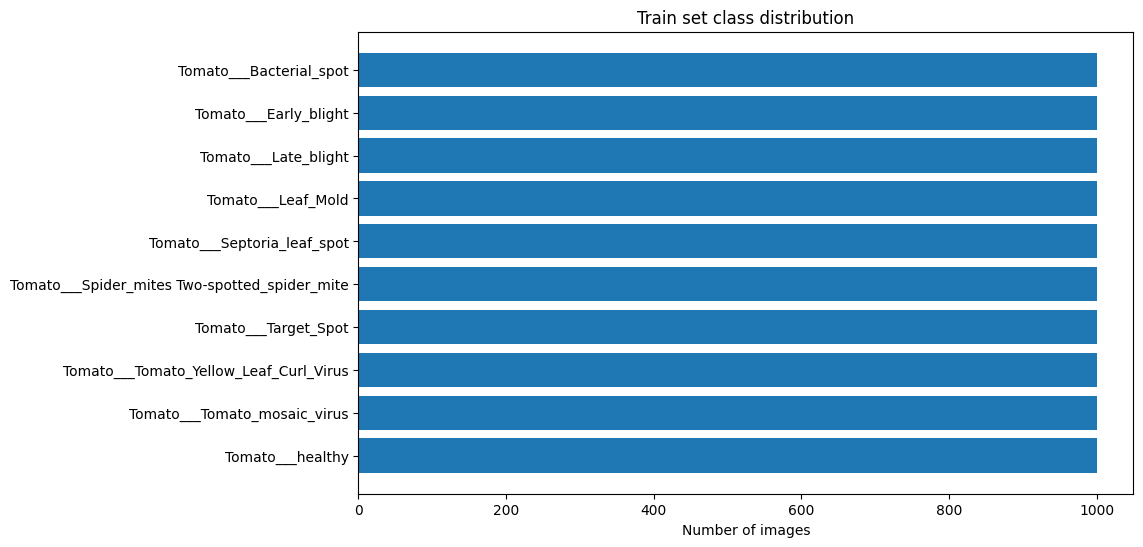

In [24]:
# Plot class distribution for train set
if len(train_counts):
    plt.figure(figsize=(10,6))
    plt.barh(train_counts['class'], train_counts['count'])
    plt.gca().invert_yaxis()
    plt.title('Train set class distribution')
    plt.xlabel('Number of images')
    plt.show()
else:
    print('No train data found to plot.')

## Show sample images (one per class)

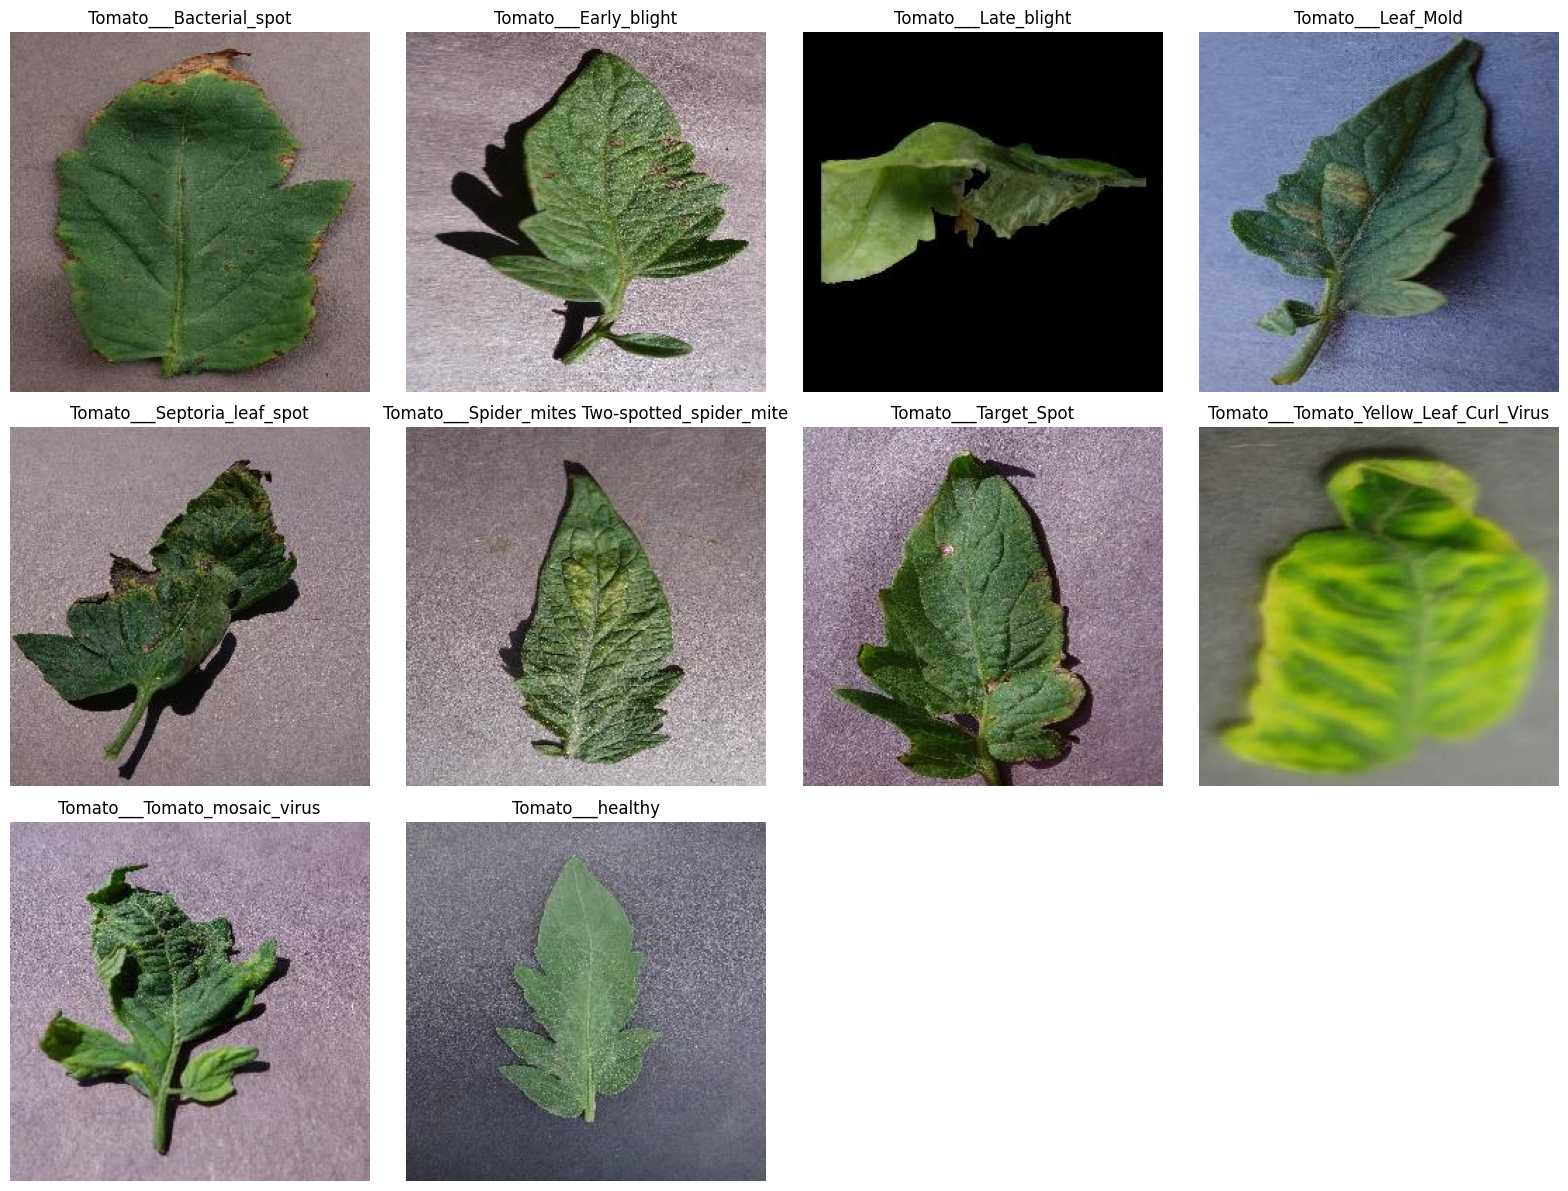

In [25]:
def show_samples(folder: Path, ncols=4, max_classes=12):
    if not folder.exists():
        print('Folder not found:', folder)
        return
    class_dirs = [d for d in sorted(folder.iterdir()) if d.is_dir()]
    class_dirs = class_dirs[:max_classes]
    n = len(class_dirs)
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(4 * ncols, 4 * nrows))
    i = 1
    for d in class_dirs:
        imgs = list(d.glob('*'))
        if not imgs:
            continue
        img_path = imgs[0]
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print('Could not open', img_path, e)
            continue
        plt.subplot(nrows, ncols, i)
        plt.imshow(img)
        plt.title(d.name)
        plt.axis('off')
        i += 1
    plt.tight_layout()

show_samples(train_dir, ncols=4, max_classes=12)

## Image size distribution (width x height) — a quick check

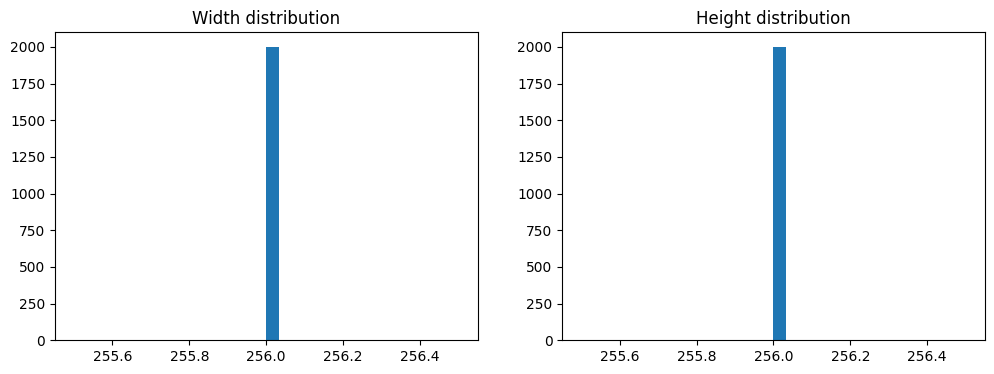

In [26]:
def gather_image_sizes(folder: Path, max_images_per_class=200):
    sizes = []
    if not folder.exists():
        return sizes
    for sub in sorted(folder.iterdir()):
        if not sub.is_dir():
            continue
        imgs = list(sub.glob('*'))[:max_images_per_class]
        for p in imgs:
            try:
                with Image.open(p) as im:
                    sizes.append(im.size)
            except Exception:
                pass
    return sizes

sizes = gather_image_sizes(train_dir, max_images_per_class=200)
if sizes:
    widths, heights = zip(*sizes)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.hist(widths, bins=30)
    plt.title('Width distribution')
    plt.subplot(1,2,2)
    plt.hist(heights, bins=30)
    plt.title('Height distribution')
    plt.show()
else:
    print('No image sizes gathered (train folder missing or empty).')

## File sample table and next steps

In [27]:
# Show a small sample table for the train set
rows = []
for sub in sorted(train_dir.iterdir()):
    if sub.is_dir():
        imgs = list(sub.glob('*'))[:5]
        for p in imgs:
            rows.append({'class': sub.name, 'file': str(p)})
df = pd.DataFrame(rows)
df.head(20)

,class,file
0,Tomato___Bacterial_spot,../data/train/Tomato___Bacterial_spot/f2f807a2...
1,Tomato___Bacterial_spot,../data/train/Tomato___Bacterial_spot/256051f1...
2,Tomato___Bacterial_spot,../data/train/Tomato___Bacterial_spot/f3bbf9c8...
3,Tomato___Bacterial_spot,../data/train/Tomato___Bacterial_spot/cb4644f6...
4,Tomato___Bacterial_spot,../data/train/Tomato___Bacterial_spot/f5d9fa8d...
5,Tomato___Early_blight,../data/train/Tomato___Early_blight/cb0e04ea-9...
6,Tomato___Early_blight,../data/train/Tomato___Early_blight/f79134d0-8...
7,Tomato___Early_blight,../data/train/Tomato___Early_blight/7b085d56-6...
8,Tomato___Early_blight,../data/train/Tomato___Early_blight/8a13da5b-4...
9,Tomato___Early_blight,../data/train/Tomato___Early_blight/9744fa97-1...


### Next steps / suggestions
- Decide on a common input size (e.g. 224 or 256) based on image size distribution
- Consider class balancing (augmentation / sampling) if distribution is skewed
- Build preprocessing pipeline (resize -> normalize -> augment) in `src/data/`
- Use this notebook to preview augmentations before training

## Pixel value distribution per class

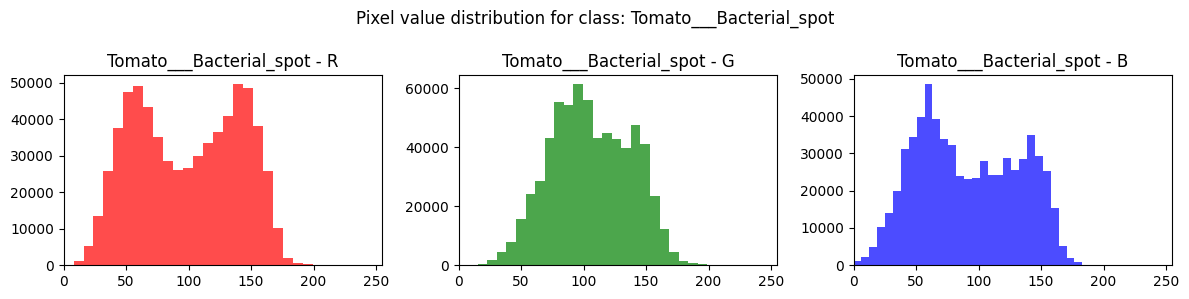

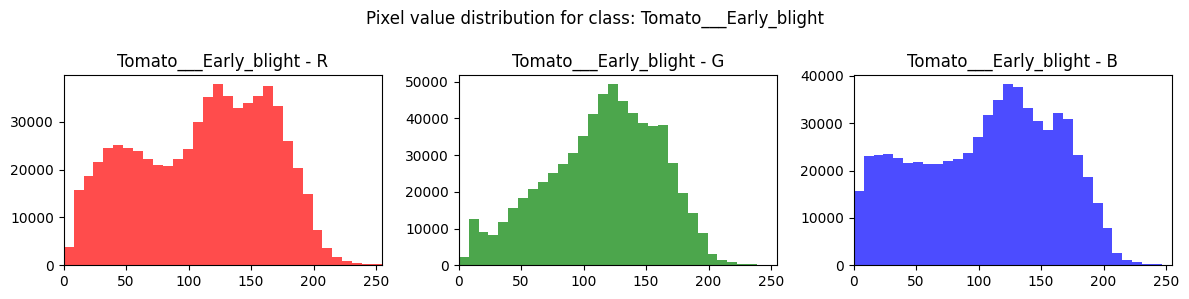

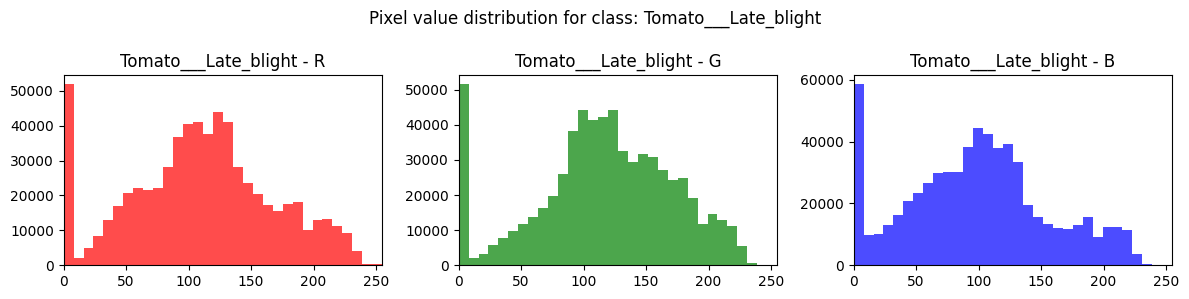

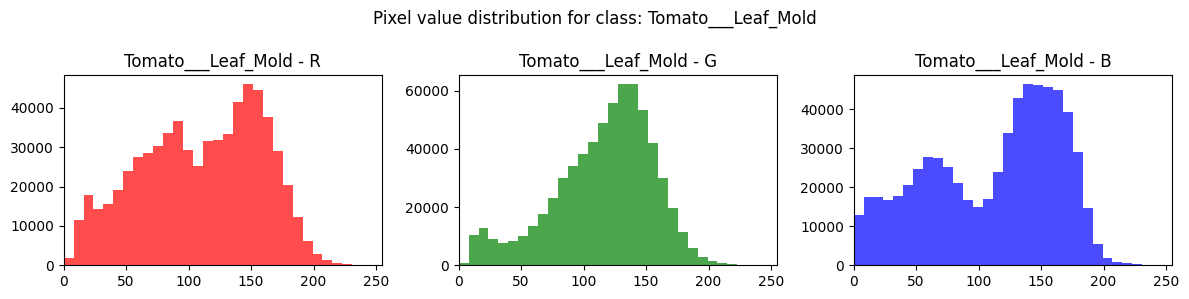

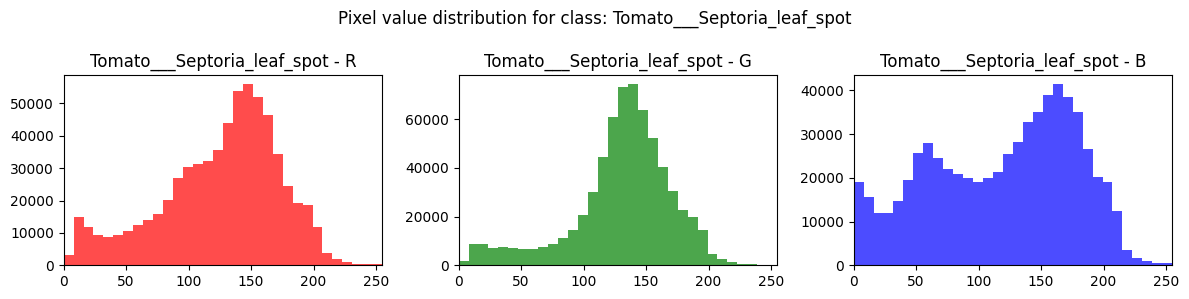

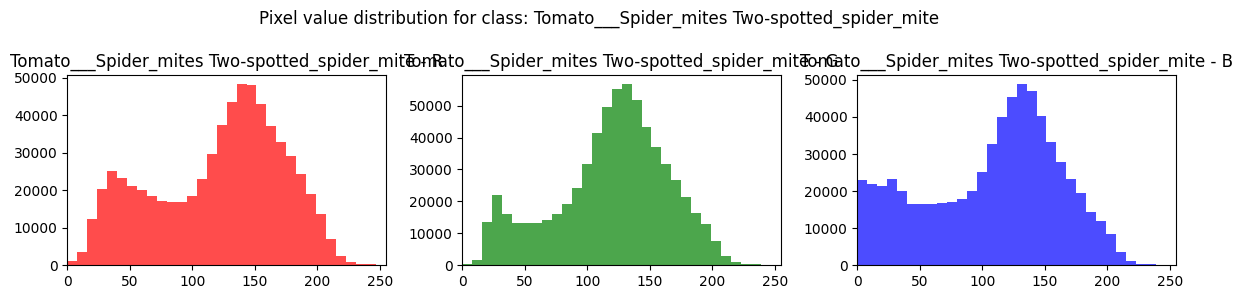

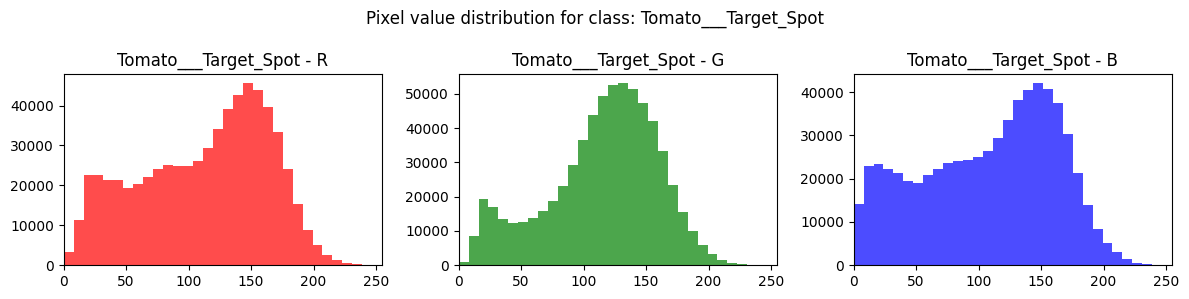

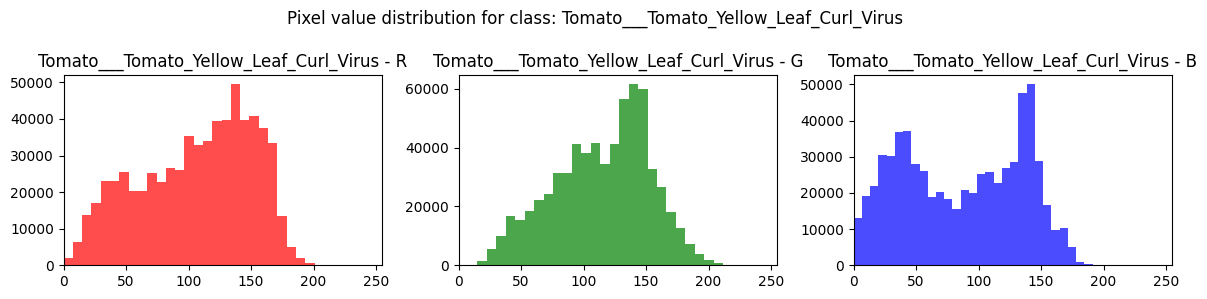

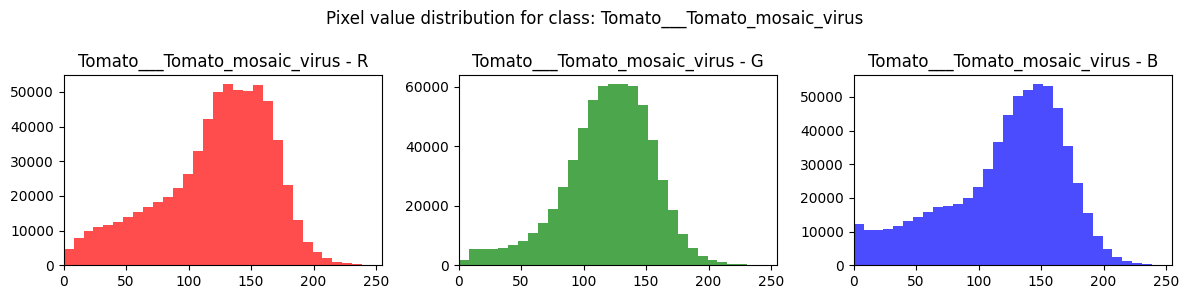

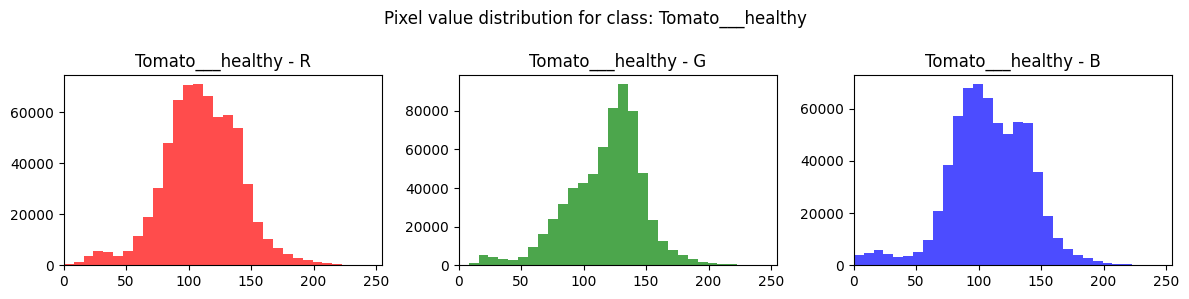

In [28]:
# Plot pixel value histograms for a sample of images per class
n_per_class = 10  # images per class to sample
bins = 32

if train_dir.exists():
    class_dirs = [d for d in sorted(train_dir.iterdir()) if d.is_dir()]
    for d in class_dirs:
        imgs = list(d.glob('*'))[:n_per_class]
        pixels = []
        for p in imgs:
            try:
                img = Image.open(p).convert('RGB')
                arr = np.asarray(img).reshape(-1, 3)  # flatten spatial dims
                pixels.append(arr)
            except Exception:
                continue
        if not pixels:
            continue
        pixels = np.concatenate(pixels, axis=0)
        plt.figure(figsize=(12,3))
        for i, color in enumerate(['R', 'G', 'B']):
            plt.subplot(1,3,i+1)
            plt.hist(pixels[:,i], bins=bins, color=color.lower(), alpha=0.7)
            plt.title(f'{d.name} - {color}')
            plt.xlim(0,255)
        plt.suptitle(f'Pixel value distribution for class: {d.name}')
        plt.tight_layout()
        plt.show()
else:
    print('Train directory not found.')

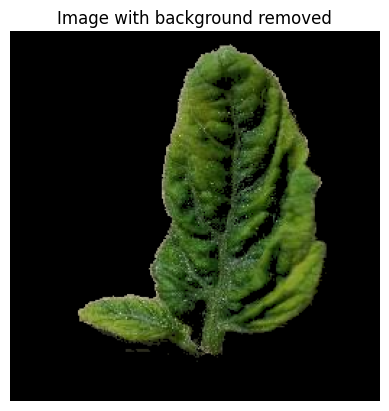

In [ ]:
from classification.src.preprocess import remove_background

# Pick the first image from the first class as a demo
demo_class = [d for d in sorted(train_dir.iterdir()) if d.is_dir()][0]
demo_img = list(demo_class.glob('*'))[0]

im = remove_background(str(demo_img))
plt.imshow(im)
plt.axis('off')
plt.title(f'Background removed — {demo_class.name}')
plt.show()


In [ ]:
from classification.src.preprocess import TomatoDataset, train_transform

# Build list of all image paths and labels
image_paths, labels = [], []
class_dirs = sorted([d for d in train_dir.iterdir() if d.is_dir()])
class_to_idx = {d.name: i for i, d in enumerate(class_dirs)}

for d in class_dirs:
    for p in d.glob('*'):
        image_paths.append(str(p))
        labels.append(class_to_idx[d.name])

train_dataset = TomatoDataset(image_paths, labels, transform=train_transform)
print(f'Dataset size: {len(train_dataset)} images, {len(class_to_idx)} classes')


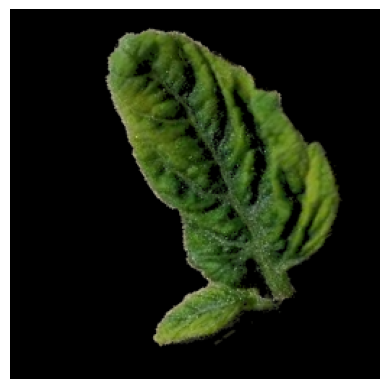

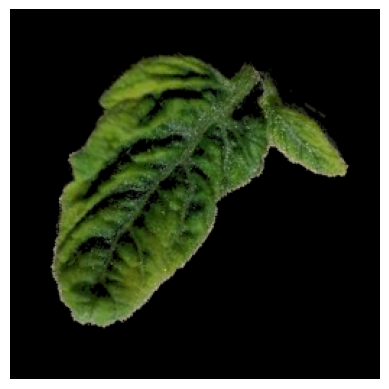

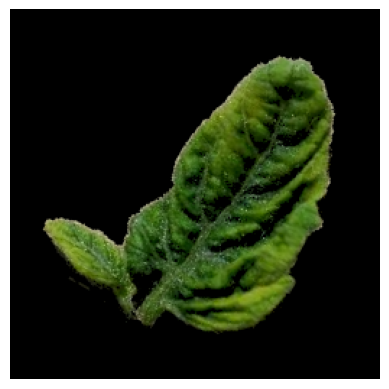

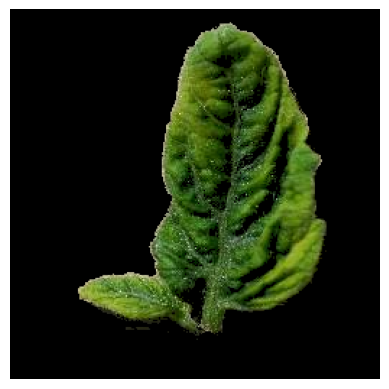

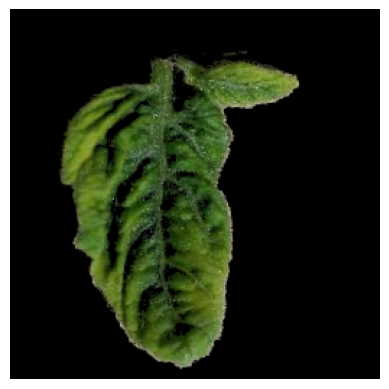

In [ ]:
# Preview augmentations on a single image
sample_path = image_paths[0]
sample = cv2.imread(sample_path)
sample = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax in axes:
    augmented = train_transform(image=sample)["image"]
    ax.imshow(augmented)
    ax.axis("off")
fig.suptitle("Augmentation previews")
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------------
# Train vs Val class distribution comparison
# ------------------------------------------------------------------
if len(train_counts) and len(val_counts):
    merged = train_counts.merge(val_counts, on='class', suffixes=('_train', '_val'), how='outer').fillna(0)
    merged = merged.sort_values('count_train', ascending=False)

    x = np.arange(len(merged))
    w = 0.4
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(x - w/2, merged['count_train'], w, label='Train')
    ax.barh(x + w/2, merged['count_val'], w, label='Val')
    ax.set_yticks(x)
    ax.set_yticklabels(merged['class'])
    ax.invert_yaxis()
    ax.legend()
    ax.set_title('Train vs Validation class distribution')
    ax.set_xlabel('Number of images')
    plt.tight_layout()
    plt.show()


## Class imbalance & channel statistics

In [ ]:
# Class imbalance ratio
if len(train_counts):
    max_count = train_counts['count'].max()
    min_count = train_counts['count'].min()
    print(f"Largest class : {max_count} images")
    print(f"Smallest class: {min_count} images")
    print(f"Imbalance ratio (max/min): {max_count / min_count:.2f}")
    print()

# Channel-wise mean and std (sampled) — useful for normalization
n_sample = 500
sampled = np.random.choice(image_paths, min(n_sample, len(image_paths)), replace=False)
pixel_data = []
for p in sampled:
    try:
        img = np.asarray(Image.open(p).convert('RGB').resize((256, 256)), dtype=np.float32) / 255.0
        pixel_data.append(img)
    except Exception:
        continue

pixel_data = np.stack(pixel_data)
channel_mean = pixel_data.mean(axis=(0, 1, 2))
channel_std  = pixel_data.std(axis=(0, 1, 2))
print(f"Channel mean (R, G, B): {channel_mean}")
print(f"Channel std  (R, G, B): {channel_std}")
